### Biased Coin Flip with Performative Prediction

Example from https://arxiv.org/pdf/2002.06673. AI was used to generate this problem summary.

- **Feature and Label:**
  - $X \in \{+1, -1\}$ is a one-dimensional feature.
  - $Y \mid X \sim \text{Bernoulli}\!\left(\tfrac{1}{2} + \mu X + \epsilon \theta X \right)$,  
    with parameters $\mu \in (0, \tfrac{1}{2})$ and $\epsilon < \tfrac{1}{2} - \mu$.

- **Model class:** Predictors are linear models of the form  
  $$f_\theta(x) = \theta x + \tfrac{1}{2}, \quad \theta \in [0,1].$$

- **Objective:** Minimize squared loss  
  $$\ell(z;\theta) = (y - f_\theta(x))^2.$$

- **Interpretation of parameters:**
  - $\mu$ controls the dependence of the coin bias on the feature $X$.
  - $\epsilon$ captures the **performative effect**, i.e., how much the outcome distribution depends on the prediction itself.

- **Special cases:**
  - If $\epsilon = 0$, outcomes are independent of predictions → reduces to standard supervised learning.
  - If $\epsilon \neq 0$, predictions influence outcomes, and the optimal model must balance predictive accuracy and induced bias.

- **Optimal solutions:**
  - **Supervised setting ($\epsilon=0$):**  
    $$f_{SL}(x) = \mathbb{E}[Y \mid X=x] = \tfrac{1}{2} + \mu x, \quad \theta_{SL} = \mu.$$
  - **Performative setting ($\epsilon \neq 0$):**  
    $$
    \theta_{PO} = \arg \min_{\theta \in [0,1]} \; \mathbb{E}_{Z \sim \mathcal{D}(\theta)} \Big( Y - \theta X - \tfrac{1}{2} \Big)^2
    = \frac{\mu}{1 - 2\epsilon}.
    $$
  - **Performativley Stable Solution:**
    $$
    \theta_{PS} = \frac{\mu}{1 - \epsilon}.
    $$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

Helper Functions

In [3]:
def sample_data(n: int, x: int, theta: float, mu: float = 0.25, epsilon: float = 0.1) -> np.ndarray:
    p = 1/2 + mu*x + epsilon*theta*x
    y = np.random.binomial(1, p, n)
    return y

def loss(x: int, y: np.ndarray, theta: float) -> float:
    return np.mean((y-theta*x - 1/2)**2)

def DPR(theta, theta_p, x, epsilon, mu):
    p = (1/2 + mu * x + epsilon*theta*x)
    return p * (1-theta_p*x-1/2)**2 + (1-p) * (0-theta_p*x-1/2)**2


### Compute Loss as a Function of Model Parameter $\theta$

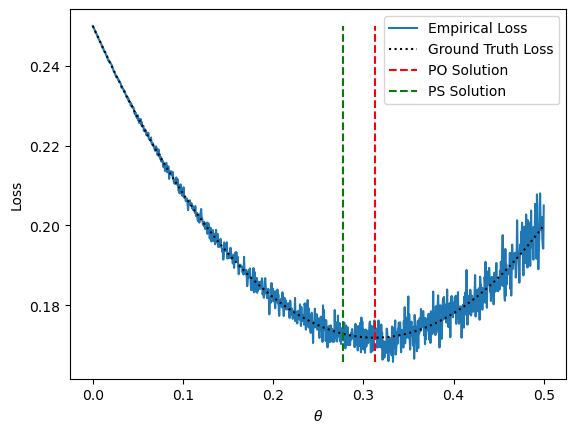

In [6]:
mu = 0.25
epsilon = 0.1
x = np.random.choice([-1, 1])
n = 10000

losses = []
theta_vals = np.linspace(0, 0.5, 1000)

for theta in theta_vals:
    y = sample_data(n, x, theta, mu, epsilon)
    l = loss(x, y, theta)
    losses.append(l)


gt_loss = (1/2 + mu * x + epsilon*theta_vals*x) * (1-theta_vals*x-1/2)**2 + (1/2 - mu * x - epsilon*theta_vals*x) * (0-theta_vals*x-1/2)**2

plt.plot(theta_vals, losses, label='Empirical Loss')
plt.plot(theta_vals, gt_loss, label='Ground Truth Loss', color='k', linestyle=':')
plt.vlines([mu/(1-2*epsilon)], ymin=min(losses), ymax=max(losses), colors='r', linestyles='dashed', label='PO Solution')
plt.vlines([mu/(1-epsilon)], ymin=min(losses), ymax=max(losses), colors='g', linestyles='dashed', label='PS Solution')

plt.ylabel('Loss')
plt.xlabel(r'$\theta$')
plt.legend()
plt.show()

### Plot the decoupled performative risk 
$DPR(\theta, \theta') = E_{Z\sim D(\theta)}\ell(Z,\theta')$

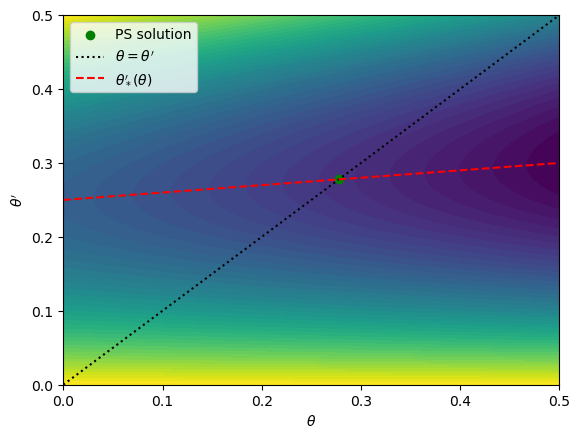

In [17]:
mu = 0.25
epsilon = 0.1
x = np.random.choice([-1, 1])
k = 1000

losses = []
theta_vals = np.linspace(0, 0.5, k)

dpr = np.zeros((k,k))
for i,j in product(range(k), range(k)):
    theta = theta_vals[i]
    theta_p = theta_vals[j]
    dpr[j,i] = DPR(theta, theta_p, x, epsilon, mu)

plt.contourf(theta_vals, theta_vals, dpr, 50)
plt.scatter(mu/(1-epsilon), mu/(1-epsilon), color='g', label='PS solution')
plt.plot([0,0.5], [0,0.5], color='k', linestyle=':', label=r"$\theta=\theta'$")

x = np.linspace(0, 0.5, 100)
theta_p_star = mu + epsilon*x
plt.plot(x, theta_p_star, color='r', label=r"$\theta_*'(\theta)$", linestyle='--')

plt.xlabel(r"$\theta$")
plt.ylabel(r"$\theta'$")
plt.legend()
plt.show()